# Project: Predicting apartment sale prices in Prague

Author: Vitalii Nechai

Data: Scraped from sreality.cz (November 2024)

## Part 1: Data preparation, model estimation

### 1. Setup and imports

#### 1.1 Importing packages & setting-up parameters

In [130]:
# standard libraries
import os
import sys
import copy
import math
from pathlib import Path

# data manipulation
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# statistics
from scipy import stats

# sklearn (models & preprocessing)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

# notebook display
from IPython.display import display, HTML
import re

# display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 250)

# set random seed for reproducibility
SEED = 42

# project paths
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / ".git").exists())
DATA_DIR = REPO_ROOT / "data"
RAW_FILE = DATA_DIR / "raw" / "updated_apartments_Praha.csv"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

#### 1.2 Importing and inspecting source data

In [131]:
# loading data from repo data folder
data_raw = pd.read_csv(RAW_FILE)
data = data_raw.copy()

In [132]:
pd.set_option('display.max_columns', data.shape[1])
pd.set_option('display.max_rows', None)

In [133]:
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (4609, 71)


,Location,Size,Price (CZK),Link,Total price,Order ID,Update,Building,Property status,Ownership,Property location,Floor,Usable area,Floorage,Balcony,Move-in date,Water,Heating,Gas,Electricity,Transportation,Energy Performance Rating,Energy Performance Certificate,Loft,Furnished,Elevator,Flat type,Terrace,Cellar,Parking,Energy Performance Indicator,Price,Garden area,Cost of living,Garage,Barrier-free access,Loggia,Reconstruction year,Waste,Telecommunications,Annuity,Acquisition of title,Final building approval year,Road,Built-up area,Construction completion date,Note on the price,ID,Discounted,Original cost,Sales commencement date,Visit site date,Visit site date to,Basin area,Basin,Status,Ceiling height,Share size,Number of owners,Starting price,Expert judgement,Minimum Bid,Auction principal,Type of auction,Venue auction,Auction sale date,1st site visit date,2nd site visit date,Advertisement of auction,Number of flats,Share size of common area
0,"Hlučkova, Praha 9 - Letňany",For sale apartment 2+kt 48 m²,7700000,https://www.sreality.cz/en/detail/sale/flat/2+kt/praha-letnany-hluckova/2482689356,7 700 000 CZK per property,N1021,Yesterday,Brick,New homes,Personal,Quiet part of municipality,1. floor of total 4 including 2 underground,48 m2,48 m2,NaN,Immediately,Water supply,Central district heating,NaN,230 V,"Road, Urban public transportation, Bus",Class G,NaN,NaN,Partially,NaN,NaN,41 m2,4 m2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Zakšínská, Praha 9 - Střížkov",For sale apartment 3+kt 98 m²,11899000,https://www.sreality.cz/en/detail/sale/flat/3+kt/praha-strizkov-zaksinska/4054574412,11 899 000 CZK per property (k jednání),N1013,Yesterday,Brick,New homes,Personal,Quiet part of municipality,6. floor of total 7 including 1 underground,98 m2,103 m2,NaN,Immediately,Water supply,Central district heating,NaN,NaN,"Highway, Road, Urban public transportation, Bus",Class G,NaN,NaN,NaN,NaN,NaN,NaN,6 m2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4 m2,NaN,NaN,"Internet, Cable TV",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Hlučkova, Praha 9 - Letňany",For sale apartment 2+kt 45 m²,7700000,https://www.sreality.cz/en/detail/sale/flat/2+kt/praha-letnany-hluckova/2918896972,7 700 000 CZK per property,N1022,Yesterday,Brick,New homes,Personal,Quiet part of municipality,1. floor of total 4 including 2 underground,45 m2,45 m2,NaN,Immediately,Water supply,Central district heating,NaN,230 V,"Train, Road, Urban public transportation, Bus",Class G,NaN,NaN,Partially,NaN,NaN,42 m2,3 m2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Musílkova, Praha 5 - Košíře",For sale apartment 3+kt 106 m² (Attic),11490000,https://www.sreality.cz/en/detail/sale/flat/3+kt/praha-kosire-musilkova/734487884,11 490 000 CZK per property (k jednání),N1062,Yesterday,Brick,In very good condition,Personal,Busy part of municipality,6. floor of total 6 including 1 underground,106 m2,100 m2,6 m2,Immediately,Water supply,Local gas,Gas pipeline,230 V,"Road, Urban public transportation, Bus",Class E Coll. 78/2013 complying with,Open Energy Performance Certificate,NaN,Partially,NaN,Attic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Kováříkova, Praha 5 - Hlubočepy",For sale apartment 3+kt 71 m²,12990000,https://www.sreality.cz/en/detail/sale/flat/3+kt/praha-hlubocepy-kovarikova/4141741388,12 990 000 CZK per property,N1005,Yesterday,Brick,In very good condition,Personal,Quiet part of municipality,1. floor of total 5 including 1 underground,71 m2,71 m2,NaN,Immediately,NaN,NaN,NaN,NaN,NaN,Class C Coll. 78/2013 complying with,NaN,NaN,Partially,NaN,

In [134]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 4609 entries, 0 to 4608
Data columns (total 71 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Location                        4609 non-null   str    
 1   Size                            4609 non-null   str    
 2   Price (CZK)                     4609 non-null   str    
 3   Link                            4609 non-null   str    
 4   Total price                     3941 non-null   str    
 5   Order ID                        3758 non-null   str    
 6   Update                          4250 non-null   str    
 7   Building                        4250 non-null   str    
 8   Property status                 4250 non-null   str    
 9   Ownership                       4250 non-null   str    
 10  Property location               1944 non-null   str    
 11  Floor                           4250 non-null   str    
 12  Usable area                     4250 non-null

#### 1.3 Inspecting missing values

In [135]:
# inspect missing values
missing_values = data.isnull().mean().mul(100).round(2)
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
display(missing_values)

Loft                              100.00
Barrier-free access               100.00
Elevator                          100.00
Basin                             100.00
Number of owners                   99.98
2nd site visit date                99.98
Share size of common area          99.98
1st site visit date                99.98
Auction sale date                  99.96
Expert judgement                   99.96
Venue auction                      99.96
Advertisement of auction           99.96
Number of flats                    99.96
Auction principal                  99.96
Type of auction                    99.96
Minimum Bid                        99.96
Share size                         99.96
Starting price                     99.96
Basin area                         99.93
Visit site date to                 99.87
Visit site date                    99.37
Ceiling height                     98.22
Discounted                         98.20
Original cost                      98.20
Annuity         

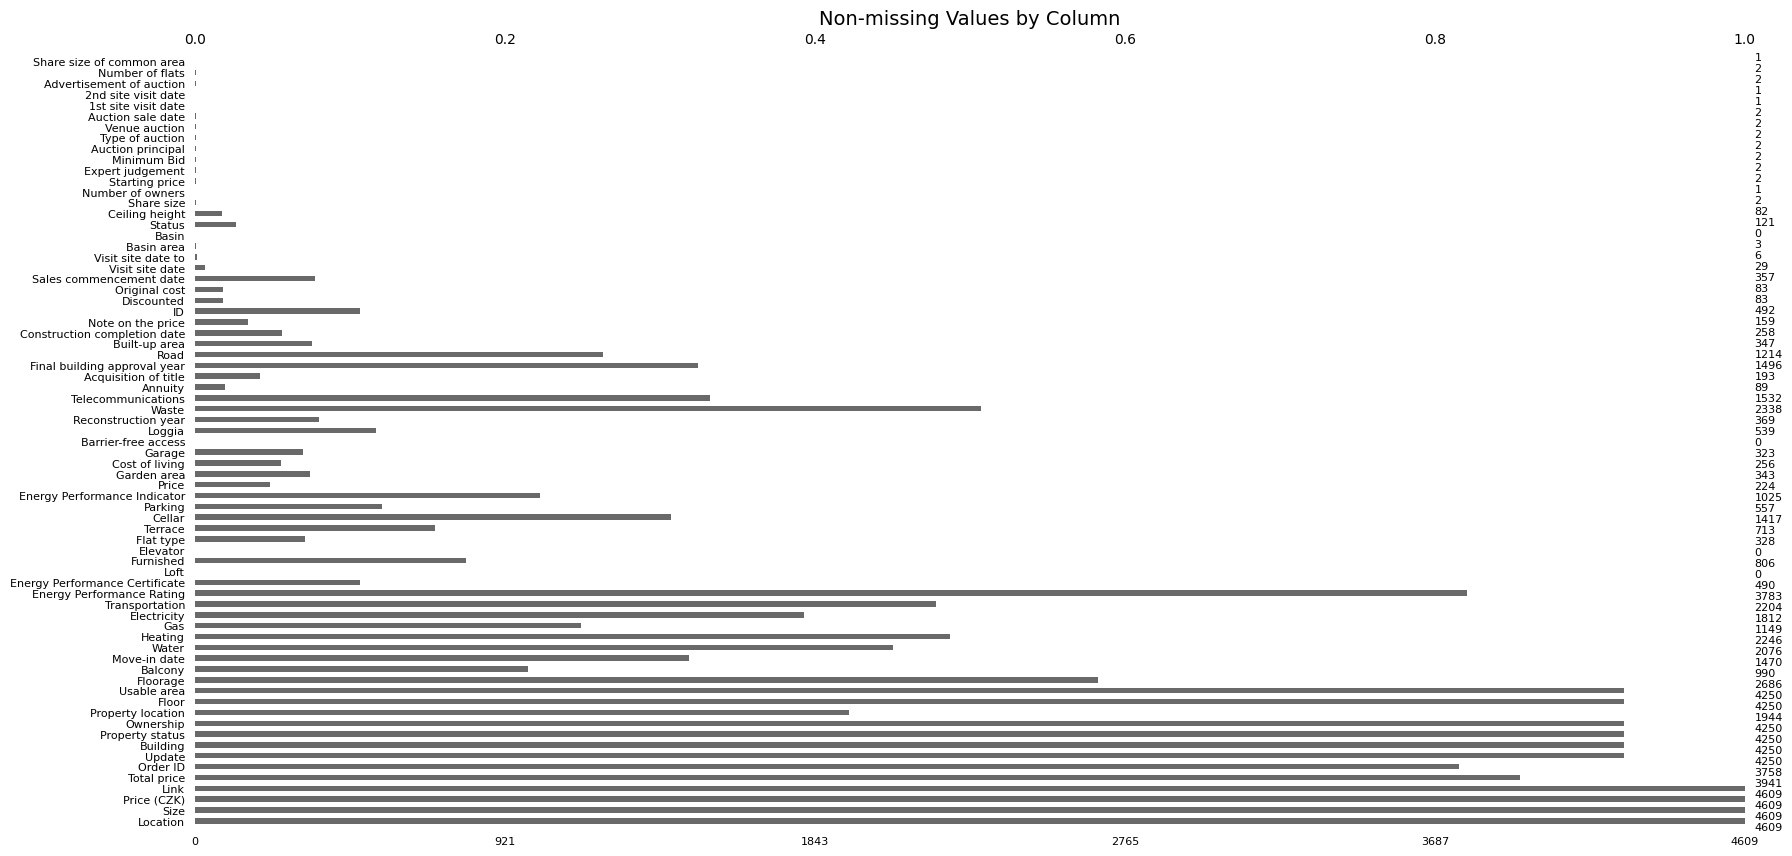

In [136]:
msno.bar(data, figsize=(20,10), fontsize=8)
plt.title("Non-missing Values by Column", fontsize=14)
plt.show()

### 2. Data cleansing and transformation

#### 2.1 Inspect basic variable information



exploratory cell, run to inspect individual variable distributions

for each variable, report:
- % of missing values
- number of unique values
- distribution of values

In [139]:
if False:  # set to True to inspect variable distributions
    for var in data.columns:
        dtype = data[var].dtype
        value_counts = pd.concat(
            [data[var].value_counts(dropna=False),
             data[var].value_counts(normalize=True, dropna=False).mul(100)],
            axis=1, keys=('counts', 'percentage')
        )
        print(f"\n\n\n{var} (dtype: {dtype}) - {len(data[var].unique())} unique values\n")
        display(value_counts.head(10))

#### 2.2 Column Names Cleaning

In [95]:
# standardize column names
data.columns = data.columns.str.lower().str.replace(' ', '_').str.strip()

#### 2.3 Target Variable Transformation

the dataset contains both 'price' and 'price_(czk)' columns. 'price' is a placeholder with inconsistent values, so we can drop it.
also we'll replace 'Information about price at agency' value with nan.

In [96]:
data = data.drop(columns=['price'])
data = data.rename(columns={'price_(czk)': 'price'})
data['price'] = data['price'].replace('Information about price at agency', np.nan)
data['price'] = pd.to_numeric(data['price'], errors='coerce')

there is a second price column 'total_price', we will later decide whether it should replace 'price' as the target variable.




#### 2.4 Remove Irrelevant Columns

remove columns that:

- are administrative or logistical and are unrelated to pricing: link, order_id, update, move-in_date, note_on_the_price, id, visit_site_date, visit_site_date_to, status, number_of_owners, 1st_site_visit_date, and 2nd_site_visit_date

- contain only missing values: loft, elevator, barrier-free access, and basin.

- are irrelevant due to location and high number of missing values: telecommunications and road

- show clear data entry errors: number_of_flats

- specific to auction listings: starting_price, expert_judgement, minimum_bid, auction_principal, type_of_auction, venue_auction, auction_sale_date, advertisement_of_auction. These columns are only relevant for 2 listings in the whole dataset.

In [97]:
# manual columns drop based on the above criterea
columns_to_drop = [
    'link', 'order_id', 'update', 'move-in_date', 'note_on_the_price', 'id',
    'visit_site_date', 'visit_site_date_to', 'status', 'number_of_owners',
    '1st_site_visit_date', '2nd_site_visit_date', 'loft', 'elevator',
    'barrier-free_access', 'basin', 'telecommunications', 'road', 'number_of_flats',
    'starting_price', 'expert_judgement', 'minimum_bid', 'auction_principal',
    'type_of_auction', 'venue_auction', 'auction_sale_date', 'advertisement_of_auction',
    'original_cost'
]

data = data.drop(columns=columns_to_drop)


#### 2.5 Basic Data Transformation

##### 2.5.1 Cleaning 'total_price' and 'discounted', chosing the target variable

clean price-related columns:
- remove text like "CZK per property" and 'CZK per property (k jednání)'
- ignore EUR conversions like here: 12 655 000 CZK (500 000 EUR) per property
- keep only CZK numeric values

In [98]:
# extract numeric CZK values, remove spaces, convert to float
for col in ['total_price', 'discounted']:
    data[f"{col}_cleaned"] = (
        data[col]
        .str.extract(r'([\d\s]+) CZK')[0]  # extract only the CZK price
        .str.replace(r'\s', '', regex=True)  # remove spaces within the number
        .astype(float)
    )

now let's compare 'price' vs. 'total_price_cleaned' and see if there're any differences between them and which column should we drop.

In [99]:
# drop rows where either is missing for fair comparison
tmp = data.dropna(subset=['price', 'total_price_cleaned']).copy()
tmp['difference'] = tmp['total_price_cleaned'] - tmp['price']

mismatches = tmp[tmp['difference'] != 0]
print(f"Found {len(mismatches)} mismatched rows "
      f"({len(mismatches)/len(tmp)*100:.1f}% of compared rows).")
print(mismatches[['price', 'total_price_cleaned', 'difference']])

Found 167 mismatched rows (4.2% of compared rows).
           price  total_price_cleaned  difference
49     8890000.0            9779000.0    889000.0
57     9999000.0            9799000.0   -200000.0
106   12310500.0           12990000.0    679500.0
107    6295000.0            7299000.0   1004000.0
150    8320500.0            8790000.0    469500.0
208   31950000.0           33390000.0   1440000.0
216    6050000.0            5999000.0    -51000.0
224   18190000.0           18390000.0    200000.0
267    8390000.0            8290000.0   -100000.0
313    7080000.0            6900000.0   -180000.0
317    6850000.0            6690000.0   -160000.0
342    7099000.0            6890000.0   -209000.0
343    7099000.0            6890000.0   -209000.0
350    7099000.0            6890000.0   -209000.0
351    7099000.0            6890000.0   -209000.0
353    8790000.0            8390000.0   -400000.0
396   12150000.0           12590000.0    440000.0
546    9570000.0            9400000.0   -170000.0

observations:
- in most cases values are very close
- some differences likely come from fees or negotiation
- a few rows have large mismatches, probably scraping or input errors (one of the entries misses a digit in a 'price' column, so the difference between columns is 800%)


choose price as Target:

- total_price_cleaned has around 15% of missing values, while price column has 5%. Since the differences between the columns are quite minimal the amount of missing values becomes a decisive factor for chosing target variable.

we need to drop 'total_price_cleaned' and 'total_price' columns

In [100]:
# explore extreme outliers
tmp['percentage_diff'] = (tmp['difference'] / tmp['price']).mul(100)
extreme_outliers = tmp[abs(tmp['percentage_diff']) > 15]
display(extreme_outliers)

,location,size,price,total_price,building,property_status,ownership,property_location,floor,usable_area,floorage,balcony,water,heating,gas,electricity,transportation,energy_performance_rating,energy_performance_certificate,furnished,flat_type,terrace,cellar,parking,energy_performance_indicator,garden_area,cost_of_living,garage,loggia,reconstruction_year,waste,annuity,acquisition_of_title,final_building_approval_year,built-up_area,construction_completion_date,discounted,sales_commencement_date,basin_area,ceiling_height,share_size,share_size_of_common_area,total_price_cleaned,discounted_cleaned,difference,percentage_diff
107,"Pod Karlovem, Praha 2 - Vinohrady",For sale apartment 3+kt 101 m² (Mezonet),6295000.0,7 299 000 CZK per property,Brick,Renovated,Cooperative,NaN,6. floor of total 5 including 1 underground,101 m2,109 m2,NaN,Water supply,NaN,Gas pipeline,NaN,NaN,Class D Coll. 148/2007 complying with,NaN,NaN,Mezonet,NaN,1 m2,NaN,NaN,NaN,NaN,NaN,NaN,2023.0,Sewerage,16155000 Kč,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7299000.0,NaN,1004000.0,15.949166
1314,"Pod Karlovem, Praha - Vinohrady",For sale apartment 3+kt 99 m²,5340000.0,6 299 000 CZK per property,Brick,New development projects,Cooperative,NaN,2. floor,99 m2,106 m2,NaN,NaN,NaN,NaN,NaN,NaN,Class D Coll. 78/2013 complying with,NaN,NaN,NaN,NaN,1 m2,1.0,147.0 kWh/m^2 /year,NaN,NaN,NaN,NaN,NaN,NaN,15650000 Kč,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6299000.0,NaN,959000.0,17.958801
1454,"Pod Karlovem, Praha - Vinohrady",For sale apartment 2+kt 46 m²,2399000.0,2 899 000 CZK per property,Brick,Renovated,Cooperative,NaN,2. floor,46 m2,48 m2,NaN,Water supply,NaN,NaN,230 V,NaN,Class D Coll. 78/2013 complying with,NaN,NaN,NaN,NaN,1 m2,1.0,147.0 kWh/m^2 /year,NaN,NaN,NaN,NaN,NaN,NaN,7561000 Kč,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2899000.0,NaN,500000.0,20.842018
2743,"Hábova, Praha - Stodůlky",For sale apartment 1+kt 27 m²,4893960.0,5 649 650 CZK per property,Mixed,New homes,Personal,NaN,4. floor,34 m2,30 m2,4 m2,NaN,NaN,NaN,NaN,NaN,Class B Coll. 78/2013 complying with,NaN,NaN,NaN,NaN,6 m2,NaN,67.0 kWh/m^2 /year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5649650.0,NaN,755690.0,15.441279
2760,"Kardašovská, Praha 9 - Hloubětín",For sale apartment 2+kt 39 m²,597767.0,5 977 667 CZK per property,Brick,New homes,Personal,NaN,3. floor of total 8 including 1 underground,39 m2,NaN,9 m2,Water supply,Central district heating,NaN,"230 V, 400 V","Highway, Road, Urban public transportation, Bus",Class B,NaN,NaN,NaN,NaN,3 m2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sewerage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5977667.0,NaN,5379900.0,899.999498
3092,"Kardausova, Praha 10 - Dolní Měcholupy",For sale apartment 2+kt 50 m²,9290000.0,2 890 000 CZK per property,Mixed,New homes,Cooperative,Quiet part of municipality,4. floor of total 5,50 m2,50 m2,NaN,Water supply,NaN,NaN,"230 V, 400 V",NaN,Class G,NaN,NaN,NaN,43 m2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sewerage,NaN,NaN,2024.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2890000.0,NaN,-6400000.0,-68.891281
3417,"Hábova, Praha - Stodůlky",For sale apartment 3+kt 71 m²,22525996.0,11 662 650 CZK per property,Mixed,New development projects,Personal,NaN,6. floor,71 m2,77 m2,5 m2,NaN,NaN,NaN,NaN,NaN,Class B Coll. 78/2013 complying with,NaN,NaN,NaN,NaN,NaN,NaN,67.0 kWh/m^2 /year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11662650.0,NaN,-10863346.0,-48.225819
3949,"Žitomírská, Praha 10 - Vršovice",For sale apartment 2+kt 50 m²,6086300.0,7 735 486 CZK per property,Brick,In good condition,Personal,Quiet part of municipality,3. floor of total 6,50 m2,NaN,NaN,Water supply,NaN,NaN,230 V,"Train, Highway, Road, Urban public transportation, Bus",Class G,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sewerage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7735486.0,NaN,1649186.0,27.096693


- most differences are below 10%, which suggests the data is consistent.

- a few listings differ by 10–20%, probably because of genuine changes or errors in the original ads.

- one or two extreme outliers are clearly just data entry mistakes.

- after cleaning, I’ll keep price as the final target, drop total_price_cleaned, and move price to the beginning of the dataset for clarity.


In [101]:
# one row had a clear scraping error (missing digit)
data.loc[2760, 'price'] *= 10

# drop remaining extreme outliers (unexplained mismatches > 15%)
bad_idx = extreme_outliers.index.drop(2760)  # exclude corrected one
data = data.drop(bad_idx)

there are two columns related to price: 'price' and 'discounted'.

wherever a discounted price exists (discounted column is not null), it is used as the final price. The price column is updated with the discounted value, replacing the original price. the discounted column is dropped after its values have been incorporated into price. then we'll drop total_price, total_price_cleaned, discounted, discounted_cleaned columns, since we've chosen 'price' as our target.


In [102]:
# if 'discounted' exists, replace price with it
mask = data['discounted_cleaned'].notna()
data.loc[mask, 'price'] = data.loc[mask, 'discounted_cleaned']

# drop redundant columns
data = data.drop(columns=['total_price', 'total_price_cleaned',
                          'discounted', 'discounted_cleaned'])

# move price to front
cols = ['price'] + [c for c in data.columns if c != 'price']
data = data[cols]


##### 2.5.2 Cleaning 'floor' column

In [103]:
data['floor'].value_counts().head(30)

floor
2. floor                                       183
1. floor                                       156
3. floor                                       150
4. floor                                       100
5. floor                                       100
2. floor of total 4                             79
6. floor                                        73
2. floor of total 5                             73
5. floor of total 6                             72
4. floor of total 5                             71
3. floor of total 5                             68
4. floor of total 4                             67
4. floor of total 6                             66
1. floor of total 5                             64
1. floor of total 4                             62
5. floor of total 5                             62
1. floor of total 6                             60
3. floor of total 6                             59
2. floor of total 6                             56
3. floor of total 4      

to make this feature useful, we’ll extract:

- floor_number – the specific floor the flat is on

- total_floors – the total number of floors in the building

some entries also mention underground floors or ground floor, which we’ll handle explicitly.

In [104]:
def extract_floor_info(text):
    """
    etracts floor number and total floors from a text description.

    """

    # return None if the value is empty, whitespace or not a string
    if not isinstance(text, str) or not text.strip():
        return pd.Series([None, None])

    text = text.lower()

    # handle 'ground floor' as 0
    if "ground floor" in text:
        floor_num = 0
    else:
        match = re.search(r"(\d+)\.?\s*floor", text)
        floor_num = int(match.group(1)) if match else None

    # extract total number of floors
    total_match = re.search(r"total\s+(\d+)", text)
    total_floors = int(total_match.group(1)) if total_match else None

    return pd.Series([floor_num, total_floors])


data[['floor_number', 'total_floors']] = data['floor'].apply(extract_floor_info)

# drop the original column after extraction
data = data.drop(columns='floor', errors='ignore')


##### 2.5.3 Cleaning Area Columns (m² suffix and missing values)

convert area-related columns from text (for example "45 m²") to numeric

In [105]:
cols_area = [
    'usable_area', 'floorage', 'balcony', 'terrace',
    'cellar', 'garden_area', 'loggia', 'built-up_area',
    'energy_performance_indicator', 'basin_area'
]

# extract numeric values
for col in cols_area:
    if col in data.columns:
        data[col] = (
            data[col].astype(str)
            .str.extract(r'([\d,.]+)', expand=False)
            .str.replace(',', '.', regex=False)
            .astype(float)
        )

# fill and cast for features where NaN = 0
fill_0_cols = [c for c in cols_area if c not in ['usable_area', 'floorage', 'built-up_area', 'energy_performance_indicator']]
fill_0_cols += ['parking', 'garage']

data[fill_0_cols] = data[fill_0_cols].fillna(0).astype('Int64')


##### 2.5.4 Convert categorical columns to boolean

'energy_performance_certificate' has only one value - 'Open Energy Performance Certificate'.

'furnished' column also has one value - 'Partially'.

we can convert those two columns to boolean.

In [ ]:
# 'energy_performance_certificate': True if certificate exists
data['energy_performance_certificate'] = data['energy_performance_certificate'].notna().astype(int)

# 'furnished': True if value == 'Partially'
data['furnished'] = (data['furnished'] == 'Partially').astype(int)

##### 2.5.5 Convert 'reconstruction_year' and final_building_approval_year columns to integer.

In [107]:
cols_to_convert = ['reconstruction_year', 'final_building_approval_year']

# convert all to Int64 (keeps NaN)
data[cols_to_convert] = data[cols_to_convert].astype('Int64')


##### 2.5.6 Convert construction_completion_date to Date




In [108]:
# convert column to datetime format
data['construction_completion_date'] = pd.to_datetime(
    data['construction_completion_date'],
    format='%d.%m.%Y',
    errors='coerce' # converts to Not a Time
)

##### 2.5.7 Extract energy class from energy_performance_rating

In [109]:
# extract the letter (A-G) directly
data['energy_performance_rating'] = data['energy_performance_rating'].str.extract(r'Class ([A-G])')


#### 2.6 Missing Data Handling and Reduction

##### 2.6.1 Data Reduction

remove unreliable data:
- drop columns with too many missing values (>60%)=
- remove clearly irrelevant features
- drop rows where price is missing or ambiguous (annuity is not NaN, share and share_size are not NaN)

some columns with more than 60% missing values were retained due to their potential importance for price prediction:

- basin_area: retained despite having only one value, might still be useful.
- discounted: kept temporarily for further analysis.
- final_building_approval_year: useful for understanding property age.
- gas: availability of gas pipelines can influence property value.

we'll also explicitly drop transportation column - it's inconsistent and doen't add value.

In [110]:
def drop_columns_with_nan(data, threshold=0.6, retain=None):
    """
    drop columns with more than threshold fraction of missing values,
    unless explicitly retained.
    """
    if retain is None:
      retain = []
    high_nan = [col for col in data.columns
                if data[col].isna().mean() > threshold and col not in retain]
    data = data.drop(columns=high_nan, errors='ignore')
    return data, high_nan




def drop_rows_with_conditions(data, conditions):
    """
    drop rows that satisfy any condition in `conditions`.
    each condition is a tuple: (column_name, lambda_condition)
    example: [('price', lambda x: x.notna())]
    """
    for column, cond in conditions:
        if column in data.columns:
            mask = cond(data[column])
            data = data[~mask]  # keep only rows that don't meet the condition
    return data

In [111]:
# configuration
retain_cols = ['basin_area', 'discounted', 'final_building_approval_year', 'gas']
nan_threshold = 0.6
drop_explicit = ['transportation']

row_conditions = [
    ('annuity', lambda x: x.notna()),
    ('share', lambda x: x.notna()),
    ('share_size', lambda x: x.notna()),
    ('price', lambda x: x.isna())
]

In [112]:
# execution
data = drop_rows_with_conditions(data, row_conditions)
data, dropped_high_nan = drop_columns_with_nan(data, threshold=nan_threshold, retain=retain_cols)
data = data.drop(columns=drop_explicit, errors='ignore')

print("dropped due to high NaN %:", dropped_high_nan)
print("explicitly dropped:", drop_explicit)

dropped due to high NaN %: ['electricity', 'flat_type', 'energy_performance_indicator', 'cost_of_living', 'reconstruction_year', 'annuity', 'acquisition_of_title', 'built-up_area', 'construction_completion_date', 'sales_commencement_date', 'ceiling_height', 'share_size', 'share_size_of_common_area']
explicitly dropped: ['transportation']


#### 2.7 Feature Engineering

##### 2.7.1 'Location' column

split location column

location combines several pieces of information in one string:
- street
- district
- cadastral area

example:
"Na Radosti, Praha 5 - Praha-Zličín"

split it into separate columns for easier analysis and encoding.

In [113]:
def split_location_column(df):
    """
    split location into street, district and cadastral_area.

    handle special cases:
    - "Praha - Praha-Čakovice" -> Praha-Čakovice goes to `cadastral_area`, `district` becomes NaN.
    - "Praha - Praha 6" -> Praha 6 goes to `district`, `cadastral_area` becomes NaN.
    """
    # split into `street` and `district_cadastral` by splitting at the first comma
    df[['street', 'district_cadastral']] = df['location'].str.split(',', n=1, expand=True)

    # identify rows where no street is present
    no_street_mask = df['district_cadastral'].isnull()  # Rows with no comma
    df.loc[no_street_mask, 'district_cadastral'] = df.loc[no_street_mask, 'street']
    df.loc[no_street_mask, 'street'] = np.nan  # Set `street` to NaN for these rows

    # further split `district_cadastral` into `district` and `cadastral_area`
    def split_district_cadastral(value):
        if pd.isnull(value):
            return pd.Series([np.nan, np.nan])
        parts = value.split(' - ', 1)
        if len(parts) == 2:
            first_part = parts[0].strip()
            second_part = parts[1].strip()

            # case 1: "Praha - Praha-Čakovice": Praha-Čakovice in cadastral_area, NaN in district
            if first_part == "Praha" and "-" in second_part:
                return pd.Series([np.nan, second_part])

            # case 2: "Praha - Praha 6": Praha 6 in district, NaN in cadastral_area
            if first_part == "Praha" and second_part.startswith("Praha ") and second_part[6:].isdigit():
                return pd.Series([second_part, np.nan])

            return pd.Series([first_part, second_part])
        return pd.Series([value.strip(), np.nan])


    df[['district', 'cadastral_area']] = df['district_cadastral'].apply(split_district_cadastral)

    df.drop(columns='district_cadastral', inplace=True)

    # post-processing fix: replace "Praha" in the `district` column with NaN
    df.loc[data['district'] == 'Praha', 'district'] = np.nan


    # if cadastral_area contains "Praha X" where X is a number, set it to NaN
    # specifically for 'Praha 9 - Praha 14' location entry
    mask = df['cadastral_area'].str.match(r'Praha \d+', na=False)
    df.loc[mask, 'cadastral_area'] = np.nan

    return df


data = split_location_column(data)

district correction

there are 10 administrative districts (obvody), but some properties were assigned to správní obvody (14 and 15), which correspond geographically to Praha 9 and Praha 10 respectively. So let's assign the right district to them.

In [114]:
# standardize district names
data['district'] = data['district'].replace({
    'Praha 14': 'Praha 9',
    'Praha 15': 'Praha 10'
})


cadastral_area imputation

fill missing cadastral_area values using the most common (mode) cadastral_area for each street.

In [115]:
missing_cadast_before = data['cadastral_area'].isna().sum()


# find the most common cadastral_area for each street
cadastral_mode_per_street = (
    data[data['cadastral_area'].notna()]
    .groupby('street')['cadastral_area']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# fill missing cadastral_area based on street
data['cadastral_area'] = data['cadastral_area'].fillna(
    data['street'].map(cadastral_mode_per_street)
)


missing_cadast_after = data['cadastral_area'].isna().sum()
print("missing cadastral area reduced from {} to {}".format(missing_cadast_before, missing_cadast_after))

missing cadastral area reduced from 177 to 56


fixing duplicates in cadastral_area (for example Praha-Troja and Troja)

In [116]:
cadastral_mapping = {
    'Praha-Čakovice': 'Čakovice',
    'Praha-Troja': 'Troja',
    'Praha-Zličín': 'Zličín',
    'Praha-Lysolaje': 'Lysolaje',
    'Praha-Dubeč': 'Dubeč'
}

data['cadastral_area'] = data['cadastral_area'].replace(cadastral_mapping)

district imputation

fill missing district values using the most common (mode) district for each cadastral area.

In [117]:

missing_district_before = data['district'].isna().sum()

# find the most common district for each cadastral area
district_mode_per_cadastral = (
    data[data['district'].notna()]
    .groupby('cadastral_area')['district']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)  # get the most common (mode) district
)

# fill missing districts using the most common district per cadastral area
data['district'] = data['district'].fillna(
    data['cadastral_area'].map(district_mode_per_cadastral)
)

# manual imputations for special cases
manual_imputations = {
    'Královice': 'Praha 10',
    'Praha-Čakovice': 'Praha 9'
}
for cadastral, district_val in manual_imputations.items():
    mask = (data['cadastral_area'] == cadastral) & (data['district'].isna())
    data.loc[mask, 'district'] = district_val


missing_district_after = data['district'].isna().sum()
print("missing districts number reduced from {} to {}".format(missing_district_before, missing_district_after))
print(data['district'].value_counts(dropna=False))


missing districts number reduced from 503 to 17
district
Praha 5     867
Praha 9     785
Praha 4     709
Praha 10    470
Praha 6     349
Praha 3     310
Praha 8     281
Praha 1     201
Praha 2     188
Praha 7     113
NaN          17
Name: count, dtype: int64


In [118]:
# drop location column since all useful information was already extracted from it. extracted features are more useful and easier to encode
data = data.drop('location', axis = 1)

##### 2.7.2 'Size' column

the size column contains textual information combining apartment layout and floor area, for example:
"For sale apartment 2+kt 52 m²"

the goal is to:
1. extract layout
2. handle special cases such as "unusual" or "6 rooms plus".
3. extract usable floor area (in square meters) as an integer.
4. remove the original text column after extraction.

In [119]:
def process_size_column(data: pd.DataFrame) -> pd.DataFrame:

    """
    extracts layout type and floor area (m²) from the 'size' column.
    """

    # etract layout
    data['layout'] = data['size'].str.extract(r'(\d+\+\w+)')

    # handle "unusual" and "6 rooms plus" cases
    data.loc[data['size'].str.contains(r'unusual', case=False, na=False), 'layout'] = 'unusual'
    data.loc[data['size'].str.contains(r'6\s*rooms\s*plus', case=False, na=False), 'layout'] = '6+'

    # extract the number of square meters (e.g., '48 m²' -> 48)
    data['square_meters'] = data['size'].str.extract(r'(\d+)\s*m²').astype('int64')

    # drop the original 'size' column
    data = data.drop(columns=['size'])

    return data

data = process_size_column(data)


##### 2.7.3 'Heating' column

the heating column contains various detailed heating descriptions, that are often combined together in the long strings such as:
"Local gas, Local solid fuels, Local electric, Central district heating"

we'll reduce detailed heating descriptions into broader categories:
- Central: central district, gas, or electric systems.
- Local: local gas, electric, or solid fuel heating.
- Mixed: multiple heating types listed.
- Other: any non-matching descriptions.

missing values are preserved as "Missing"

In [120]:
def simplify_heating(heating: str) -> str:
    """
    simplifies heating descriptions into broader categories.
    """

    if pd.isna(heating) or heating == 'Missing':
        return 'Missing'
    heating = heating.lower()

    if 'central district heating' in heating or 'central gas' in heating or 'central electric' in heating:
        return 'Central'
    elif 'local gas' in heating or 'local electric' in heating or 'local solid fuels' in heating:
        return 'Local'
    elif ',' in heating:  # If multiple heating sources are listed
        return 'Mixed'
    else:
        return 'Other'

data['heating'] = data['heating'].apply(simplify_heating)

print(data['heating'].value_counts())


heating
Missing    2203
Central    1530
Local       445
Other        91
Mixed        21
Name: count, dtype: int64


##### 2.7.4 Category Consolidation for 'water' and 'waste'


In [121]:
# regroup rare water categories
water_mix = {
    'Local water source, Water supply',
    'Local water source, Water supply, Rainwater retention tank',
    'Water supply, Rainwater retention tank',
    'Water supply, Well'
}

data['water'] = data['water'].replace(list(water_mix), 'mix')

# Regroup rare waste categories
waste_other = {
    'Dry well',
    'Facility sewerage plant',
    'Septic',
    'Sewerage, Facility sewerage plant',
    'Wastewater trap'
}

data['waste'] = data['waste'].replace(list(waste_other), 'other')


##### 2.7.5 Imputing property_location based on cadastral_area.

fill missing values by taking the most frequent (mode) property_location within each cadastral_area.

In [122]:
# compute the mode of property_location per cadastral_area
mode_per_cadastral = (
    data[data['property_location'].notna()]
    .groupby('cadastral_area')['property_location']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# fill missing property_location where a valid mode exists
data['property_location'] = data.apply(
    lambda row: mode_per_cadastral[row['cadastral_area']]
    if pd.isna(row['property_location']) and row['cadastral_area'] in mode_per_cadastral.index
    else row['property_location'],
    axis=1
)

data['property_location'].value_counts()

property_location
Quiet part of municipality    2608
Municipality centre           1429
Housing development            114
Periphery of municipality       41
Busy part of municipality       38
Name: count, dtype: int64

In [123]:
# save cleaned dataset
cleaned_eda_ready_path = PROCESSED_DIR / "cleaned_eda_ready.parquet"
data.to_parquet(cleaned_eda_ready_path, index=False)

### 2.8 Transformations following EDA

the following transformations were identified during exploratory analysis and applied here for reproducibility.

##### 2.8.1 Remove cooperative and state-owned listings and entire 'ownership' column

as identified in 3.1.4 'Ownership' section of exploratory data analysis 'Cooperative' flats don't display the full flat value. we'll also remove state-owned flats as there're only 7 of them and they introduce some non-market pricing and keep the variable very imbalanced. since there will be only one category left we can remove the whole column enirely.

In [124]:
# remove cooperative and State-owned/municipal ownership listings
mask = data['ownership'].isin(['Cooperative', 'State-owned/municipal'])
data = data.loc[~mask].reset_index(drop=True)

# drop ownership column
data = data.drop(columns=['ownership'])

##### 2.8.2 Remove invalid values

the garden that has area of 1800 m2 is definitely false, based on the street it's located on it seems that the garden is actually a public square.

In [125]:
data.loc[1022, 'garden_area'] = 0

year 31 is also invalid

In [126]:
data.loc[data['final_building_approval_year'] == 31, 'final_building_approval_year'] = np.nan

floor number should always be less or equal to total floors, other values are invalid and should be removed.

In [127]:
mask = (data['floor_number'] > data['total_floors']) & \
       data['floor_number'].notna() & data['total_floors'].notna()
# cleaning the invalid floor_number and total_floors values
data.loc[mask, ['floor_number', 'total_floors']] = np.nan

2.8.3 Dtype conversion

In [128]:
for col in data.select_dtypes(include=['int', 'Int64', 'Float64']).columns:
    data[col] = data[col].astype(float)

In [129]:
# save cleaned dataset 
cleaned_model_ready_path = PROCESSED_DIR / "cleaned_model_ready.parquet"
data.to_parquet(cleaned_model_ready_path, index=False)